## 1. Install Dependencies

In [1]:
!pip install torch torchvision timm albumentations opencv-python-headless matplotlib seaborn tqdm -q

## 2. Imports & Configuration

In [3]:
import os
import math
import random
import glob
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Hyperparameters (matches the paper''s Implementation Details section) ────
CFG = {
    'img_size'    : 352,
    'batch_size'  : 16,
    'epochs'      : 100,
    'lr'          : 1e-4,
    'weight_decay': 1e-4,
    'num_workers' : 4,
    'checkpoint'  : './checkpoints',
    'pvt_backbone': 'pvt_v2_b2',

    'd_model'     : 64,
    'd_state'     : 8,
    'mamba_chunk' : 32,

    'dec_dim'     : 64,
    'window'      : 8,
    'num_heads'   : 4,

    'lambda_pred' : 1.0,
    'lambda_edge' : 0.3,

    'train_ratio' : 0.9,   # Kvasir/ClinicDB in-distribution split ratio (ColonDB/ETIS are 100% zero-shot test)

    # ── Dataset roots -- filled in by autodetect_roots() below; override manually if needed ──
    'data_roots'  : {'kvasir': None, 'clinicdb': None, 'colondb': None, 'etis': None},
}

os.makedirs(CFG['checkpoint'], exist_ok=True)
print('Config loaded.')

Using device: cuda
GPU: Tesla T4
Config loaded.


## 3. Locate Datasets on Kaggle

In [3]:
!ls /kaggle/input 2>/dev/null || echo "Not running on Kaggle -- set CFG[\'data_roots\'] manually below."

datasets


In [4]:
def autodetect_roots(base='/kaggle/input'):
    """
    Scans /kaggle/input for the four datasets based on their known folder
    signatures (see markdown table above). Returns a dict of {name: path}.
    A value of None means autodetection failed for that dataset -- set it
    manually in CFG[\'data_roots\'] after checking the Data Explorer panel.
    """
    found = {'kvasir': None, 'clinicdb': None, 'colondb': None, 'etis': None}
    if not os.path.isdir(base):
        return found

    for dirpath, dirnames, filenames in os.walk(base):
        low = dirpath.lower()
        dirset = set(d.lower() for d in dirnames)

        # Kvasir-SEG: has images/ + masks/ subdirs, and 'kvasir' in the path
        if {'images', 'masks'} <= dirset and 'kvasir' in low and found['kvasir'] is None:
            found['kvasir'] = dirpath

        # CVC-ClinicDB: has a PNG/ subdir containing Original/ and Ground Truth/
        if 'png' in dirset and found['clinicdb'] is None:
            png_dir = os.path.join(dirpath, [d for d in dirnames if d.lower() == 'png'][0])
            try:
                sub = set(d.lower() for d in os.listdir(png_dir))
                if 'original' in sub and any('ground' in s for s in sub):
                    found['clinicdb'] = dirpath
            except OSError:
                pass

        # ETIS / ColonDB: flat images/ + masks/, disambiguated by keyword in path
        if {'images', 'masks'} <= dirset:
            if ('etis' in low or 'larib' in low) and found['etis'] is None:
                found['etis'] = dirpath
            elif 'colon' in low and found['colondb'] is None:
                found['colondb'] = dirpath

    return found


detected = autodetect_roots()
print('Autodetected dataset roots:')
for k, v in detected.items():
    print(f'  {k:10s}: {v}')

# Fill in CFG, keeping any manual overrides already set above
for k, v in detected.items():
    if CFG['data_roots'][k] is None:
        CFG['data_roots'][k] = v

missing = [k for k, v in CFG['data_roots'].items() if v is None]
if missing:
    print(f"\nWARNING: could not autodetect {missing}. Set CFG['data_roots'][...] manually, e.g.:")
    print("  CFG['data_roots']['etis'] = '/kaggle/input/<exact-folder-name>'")
else:
    print('\nAll four dataset roots located.')

Autodetected dataset roots:
  kvasir    : /kaggle/input/datasets/debeshjha1/kvasirseg/Kvasir-SEG/Kvasir-SEG
  clinicdb  : /kaggle/input/datasets/balraj98/cvcclinicdb
  colondb   : /kaggle/input/datasets/giahnggg/colondb
  etis      : /kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb

All four dataset roots located.


## 4. Build Image/Mask Pairs (one loader per dataset layout)

In [5]:
IMG_EXTS = ('*.jpg', '*.jpeg', '*.png', '*.tif', '*.tiff')

def _glob_multi(directory, patterns=IMG_EXTS):
    paths = []
    for p in patterns:
        paths.extend(Path(directory).glob(p))
    return sorted(paths)


def build_pairs_flat(root, img_subdir='images', mask_subdir='masks'):
    """
    Layout: root/images/*, root/masks/*   (used by ETIS-LaribPolypDB and CVC-ColonDB)
    Matches each image to a mask of the same stem, trying several extensions.
    """
    root = Path(root)
    img_dir, mask_dir = root / img_subdir, root / mask_subdir
    pairs = []
    for ip in _glob_multi(img_dir):
        mp = None
        for ext in ('.jpg', '.jpeg', '.png', '.tif', '.tiff'):
            cand = mask_dir / (ip.stem + ext)
            if cand.exists():
                mp = cand
                break
        if mp is None and (mask_dir / ip.name).exists():
            mp = mask_dir / ip.name
        if mp is not None:
            pairs.append((str(ip), str(mp)))
    return pairs


def build_pairs_kvasir(root):
    """
    Layout: root/Kvasir-SEG/{images,masks}/*  (nested folder, per the Kaggle upload)
    Falls back to root/{images,masks}/* if the nested folder isn't present.
    """
    root = Path(root)
    inner = root / 'Kvasir-SEG'
    target = inner if (inner / 'images').exists() else root
    return build_pairs_flat(target, 'images', 'masks')


def build_pairs_clinicdb(root):
    """
    Layout: root/PNG/Original/*.png, root/PNG/Ground Truth/*.png
    """
    root = Path(root)
    img_dir = root / 'PNG' / 'Original'
    mask_dir = root / 'PNG' / 'Ground Truth'
    pairs = []
    for ip in _glob_multi(img_dir):
        mp = mask_dir / ip.name
        if mp.exists():
            pairs.append((str(ip), str(mp)))
    return pairs


print('Pair-building functions ready: build_pairs_flat, build_pairs_kvasir, build_pairs_clinicdb')

Pair-building functions ready: build_pairs_flat, build_pairs_kvasir, build_pairs_clinicdb


## 5. Load Datasets and Build the Shared-Training Split

In [6]:
def stratified_split(pairs, train_ratio, seed):
    pairs = list(pairs)
    random.Random(seed).shuffle(pairs)
    split = int(len(pairs) * train_ratio)
    return pairs[:split], pairs[split:]


assert all(v is not None for v in CFG['data_roots'].values()), \
    "One or more dataset roots is None -- fix CFG['data_roots'] before continuing (see Section 3)."

kvasir_pairs   = build_pairs_kvasir(CFG['data_roots']['kvasir'])
clinicdb_pairs = build_pairs_clinicdb(CFG['data_roots']['clinicdb'])
colondb_pairs  = build_pairs_flat(CFG['data_roots']['colondb'])
etis_pairs     = build_pairs_flat(CFG['data_roots']['etis'])

print(f'Kvasir-SEG          : {len(kvasir_pairs)} pairs found')
print(f'CVC-ClinicDB        : {len(clinicdb_pairs)} pairs found')
print(f'CVC-ColonDB         : {len(colondb_pairs)} pairs found  (100% zero-shot test)')
print(f'ETIS-LaribPolypDB   : {len(etis_pairs)} pairs found  (100% zero-shot test)')

for name, pairs, expected in [('Kvasir-SEG', kvasir_pairs, 1000),
                                ('CVC-ClinicDB', clinicdb_pairs, 612),
                                ('CVC-ColonDB', colondb_pairs, 380),
                                ('ETIS-LaribPolypDB', etis_pairs, 196)]:
    if len(pairs) != expected:
        print(f"  NOTE: {name} found {len(pairs)} pairs, paper reports {expected}. "
              f"Check the folder layout / file extensions if this looks wrong.")

# ── In-distribution 90/10 splits (Kvasir, ClinicDB) ──────────────────────────
kvasir_train, kvasir_test     = stratified_split(kvasir_pairs,   CFG['train_ratio'], SEED)
clinicdb_train, clinicdb_test = stratified_split(clinicdb_pairs, CFG['train_ratio'], SEED)

# ── Pooled training set (this is what the model actually trains on) ─────────
TRAIN_PAIRS = kvasir_train + clinicdb_train
random.Random(SEED).shuffle(TRAIN_PAIRS)

# ── Pooled in-distribution validation set (checkpoint selection only) ───────
VAL_PAIRS = kvasir_test + clinicdb_test

print(f'\nPooled TRAIN set   : {len(TRAIN_PAIRS)}  (Kvasir {len(kvasir_train)} + ClinicDB {len(clinicdb_train)})')
print(f'Pooled VAL set     : {len(VAL_PAIRS)}  (Kvasir {len(kvasir_test)} + ClinicDB {len(clinicdb_test)}) -- used ONLY for checkpointing')
print(f'\nFour held-out test sets for final evaluation:')
print(f'  Kvasir test        : {len(kvasir_test)}   (in-distribution)')
print(f'  ClinicDB test      : {len(clinicdb_test)}   (in-distribution)')
print(f'  CVC-ColonDB (full) : {len(colondb_pairs)}  (zero-shot)')
print(f'  ETIS (full)        : {len(etis_pairs)}  (zero-shot)')

Kvasir-SEG          : 1000 pairs found
CVC-ClinicDB        : 612 pairs found
CVC-ColonDB         : 380 pairs found  (100% zero-shot test)
ETIS-LaribPolypDB   : 196 pairs found  (100% zero-shot test)

Pooled TRAIN set   : 1450  (Kvasir 900 + ClinicDB 550)
Pooled VAL set     : 162  (Kvasir 100 + ClinicDB 62) -- used ONLY for checkpointing

Four held-out test sets for final evaluation:
  Kvasir test        : 100   (in-distribution)
  ClinicDB test      : 62   (in-distribution)
  CVC-ColonDB (full) : 380  (zero-shot)
  ETIS (full)        : 196  (zero-shot)


## 6. Dataset & Augmentation

In [7]:
def get_train_transforms(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
        A.GaussNoise(p=0.2),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_val_transforms(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


class PolypDataset(Dataset):
    """Generic image/mask dataset -- works for any of the four sources above,
    since build_pairs_* already normalises everything to (image_path, mask_path)."""
    def __init__(self, pairs, transforms=None):
        self.pairs      = pairs
        self.transforms = transforms

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if self.transforms:
            aug   = self.transforms(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask']

        mask = (mask > 127).float().unsqueeze(0)
        return image, mask


def make_loader(pairs, transforms, cfg, shuffle):
    ds = PolypDataset(pairs, transforms)
    return DataLoader(ds, batch_size=cfg['batch_size'], shuffle=shuffle,
                       num_workers=cfg['num_workers'], pin_memory=True)


train_loader = make_loader(TRAIN_PAIRS, get_train_transforms(CFG['img_size']), CFG, shuffle=True)
val_loader   = make_loader(VAL_PAIRS,   get_val_transforms(CFG['img_size']),   CFG, shuffle=False)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 91 | Val batches: 11


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### 7.1 Edge Attention Gate — Wavelet Edge Decomposition

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
#  5.1  Edge Attention Gate  –  Wavelet Edge Decomposition variant
# ─────────────────────────────────────────────────────────────────────────────
#
#  Replace the depthwise-conv edge detector with a 2-D Discrete Wavelet
#  Transform (DWT). A single-level Haar DWT on f1 yields four subbands:
#
#      LL  – low x low   (smooth regions, approximation)
#      LH  – low x high  (horizontal edges)
#      HL  – high x low  (vertical edges)
#      HH  – high x high (diagonal / corner edges)
#
#  Edge information  = LH + HL + HH  (mathematically grounded, not learned)
#  Smooth regions    = LL
#
#  The sigmoid gate sigma is computed from:
#      - edge_feat : channel-projected [LH | HL | HH]  (fine boundary signal)
#      - f4_up     : upsampled semantic context         (regional meaning)
#
#  sigma = sigmoid( Conv1x1( Concat(edge_feat, f4_up) ) )
#
#  Gated output:
#      fe = edge_feat * sigma  +  f4_up * (1 - sigma)
#      sigma~1 -> trust wavelet edges (boundary pixel)
#      sigma~0 -> trust semantic f4   (interior pixel)
#
#  Implementation notes:
#      - Pure PyTorch Haar filters: fixed, not learned, correct by construction
#      - No pywt / no custom CUDA – runs on Kaggle T4 / P100 out of the box
#      - DWT halves spatial size (stride-2); we upsample back so shapes match f1
#      - The LL subband is discarded here but trivially recoverable if needed
# ─────────────────────────────────────────────────────────────────────────────

def _haar_filters(device, dtype):
    """
    Return the four 2-D Haar analysis filters as (1,1,2,2) tensors.

    Haar 1-D:  Lo = [+1, +1] / sqrt(2)  (averaging / low-pass)
               Hi = [+1, -1] / sqrt(2)  (differencing / high-pass)

    2-D filters are outer products:
        LL = Lo x Lo,  LH = Lo x Hi,  HL = Hi x Lo,  HH = Hi x Hi
    """
    s = 1.0 / (2.0 ** 0.5)
    lo = torch.tensor([ s,  s], device=device, dtype=dtype)
    hi = torch.tensor([ s, -s], device=device, dtype=dtype)
    LL = torch.outer(lo, lo).view(1, 1, 2, 2)
    LH = torch.outer(lo, hi).view(1, 1, 2, 2)
    HL = torch.outer(hi, lo).view(1, 1, 2, 2)
    HH = torch.outer(hi, hi).view(1, 1, 2, 2)
    return LL, LH, HL, HH


def dwt2d(x):
    """
    Single-level 2-D Haar DWT, pure PyTorch, channel-wise, no external deps.

    Args:
        x : (B, C, H, W)  – H and W are reflect-padded to even if needed

    Returns:
        LL, LH, HL, HH – each (B, C, H//2, W//2)

    Filters are applied channel-wise (groups=C) with stride 2, giving the
    standard critically-sampled DWT decimation.
    """
    B, C, H, W = x.shape
    if H % 2 != 0 or W % 2 != 0:
        x = F.pad(x, (0, W % 2, 0, H % 2), mode='reflect')

    LL_f, LH_f, HL_f, HH_f = _haar_filters(x.device, x.dtype)
    # Expand scalar filter to (C, 1, 2, 2) for depthwise grouped conv
    LL_f = LL_f.expand(C, -1, -1, -1)
    LH_f = LH_f.expand(C, -1, -1, -1)
    HL_f = HL_f.expand(C, -1, -1, -1)
    HH_f = HH_f.expand(C, -1, -1, -1)

    LL = F.conv2d(x, LL_f, stride=2, groups=C)
    LH = F.conv2d(x, LH_f, stride=2, groups=C)
    HL = F.conv2d(x, HL_f, stride=2, groups=C)
    HH = F.conv2d(x, HH_f, stride=2, groups=C)
    return LL, LH, HL, HH


class EdgeAttentionGate(nn.Module):
    """
    Wavelet Edge Decomposition EAG.

    Inputs
    ------
    f1 : (B, c_low,  H,   W  )  PVTv2-b2 stage-1 (1/4 scale, 64 ch)
    f4 : (B, c_high, h,   w  )  PVTv2-b2 stage-4 (1/32 scale, 512 ch)

    Pipeline
    --------
    1. Haar DWT on f1  ->  LL, LH, HL, HH  at (H/2, W/2)
    2. Stack edge subbands [LH | HL | HH]  (3 x c_low channels)
       -> Conv1x1 + BN + ReLU  -> edge_feat  (c_low ch, H/2, W/2)
       -> bilinear upsample    -> edge_feat  (c_low ch, H,   W  )
       -> DWConv3x3 refinement  -> edge_feat  (c_low ch, H,   W  )
    3. proj_high(f4) + bilinear upsample  -> f4_up  (c_low ch, H, W)
    4. sigma = sigmoid( gate( [edge_feat | f4_up] ) )    (1 ch, H, W)
    5. fe = edge_feat * sigma  +  f4_up * (1 - sigma)

    Returns
    -------
    fe    : (B, c_low, H, W)   gated edge-guided feature
    sigma : (B, 1,     H, W)   boundary probability map (used for aux loss)
    """

    def __init__(self, c_low: int, c_high: int):
        super().__init__()

        # Project f4 to c_low channels for spatial alignment
        self.proj_high = nn.Conv2d(c_high, c_low, 1)

        # Fuse three edge subbands (3 x c_low) -> c_low channels
        self.edge_proj = nn.Sequential(
            nn.Conv2d(c_low * 3, c_low, 1, bias=False),
            nn.BatchNorm2d(c_low),
            nn.ReLU(inplace=True),
        )

        # DWConv refinement: adds local spatial context to wavelet edge features
        self.edge_refine = nn.Sequential(
            nn.Conv2d(c_low, c_low, 3, padding=1, groups=c_low, bias=False),
            nn.BatchNorm2d(c_low),
            nn.ReLU(inplace=True),
        )

        # Sigmoid gate: [edge_feat | f4_up] (2 x c_low) -> 1-channel gate logit
        self.gate = nn.Sequential(
            nn.Conv2d(c_low * 2, c_low, 1, bias=False),
            nn.BatchNorm2d(c_low),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_low, 1, 1),
        )

    def forward(self, f1, f4):
        B, C, H, W = f1.shape

        # ── 1. Haar DWT on f1 ─────────────────────────────────────────────────
        _LL, LH, HL, HH = dwt2d(f1)                     # each: (B, C, H/2, W/2)

        # ── 2. Edge subbands -> edge_feat at f1 resolution ────────────────────
        edge_subbands = torch.cat([LH, HL, HH], dim=1)   # (B, 3C, H/2, W/2)
        edge_feat = self.edge_proj(edge_subbands)          # (B,  C, H/2, W/2)
        edge_feat = F.interpolate(edge_feat, size=(H, W), # (B,  C, H,   W  )
                                  mode='bilinear', align_corners=False)
        edge_feat = self.edge_refine(edge_feat)            # (B,  C, H,   W  )

        # ── 3. Semantic guidance from f4 ──────────────────────────────────────
        f4_up = F.interpolate(self.proj_high(f4),
                              size=(H, W), mode='bilinear',
                              align_corners=False)         # (B,  C, H,   W  )

        # ── 4. Sigmoid gate ───────────────────────────────────────────────────
        sigma = torch.sigmoid(
            self.gate(torch.cat([edge_feat, f4_up], dim=1))
        )                                                  # (B,  1, H,   W  )

        # ── 5. Gated fusion ───────────────────────────────────────────────────
        fe = edge_feat * sigma + f4_up * (1.0 - sigma)   # (B,  C, H,   W  )

        return fe, sigma


# ── Sanity check ──────────────────────────────────────────────────────────────
# PVTv2-b2 feature sizes at img_size=352:
#   f1: (B, 64,  88, 88)  -- 1/4  of 352
#   f4: (B, 512, 11, 11)  -- 1/32 of 352
_eag = EdgeAttentionGate(c_low=64, c_high=512)
_f1  = torch.randn(2, 64,  88, 88)
_f4  = torch.randn(2, 512, 11, 11)
_fe, _sigma = _eag(_f1, _f4)
assert _fe.shape    == (2, 64, 88, 88), f'fe shape: {_fe.shape}'
assert _sigma.shape == (2,  1, 88, 88), f'sigma shape: {_sigma.shape}'
print(f'WaveletEAG ok  ->  fe: {tuple(_fe.shape)}   sigma: {tuple(_sigma.shape)}')

# DWT subband shapes
_LL, _LH, _HL, _HH = dwt2d(_f1)
print(f'DWT subbands from f1 {tuple(_f1.shape)}:')
print(f'  LL {tuple(_LL.shape)}  smooth/region')
print(f'  LH {tuple(_LH.shape)}  horizontal edges')
print(f'  HL {tuple(_HL.shape)}  vertical edges')
print(f'  HH {tuple(_HH.shape)}  diagonal edges')

_n = sum(p.numel() for p in _eag.parameters())
print(f'WaveletEAG params: {_n:,}')
del _eag, _f1, _f4, _fe, _sigma, _LL, _LH, _HL, _HH


WaveletEAG ok  ->  fe: (2, 64, 88, 88)   sigma: (2, 1, 88, 88)
DWT subbands from f1 (2, 64, 88, 88):
  LL (2, 64, 44, 44)  smooth/region
  LH (2, 64, 44, 44)  horizontal edges
  HL (2, 64, 44, 44)  vertical edges
  HH (2, 64, 44, 44)  diagonal edges
WaveletEAG params: 54,337


### 7.2 Cross-Scale Mamba Module (CSMM)

In [9]:
def selective_scan(x, dt, A, B, C, D, chunk_size=64):
    """
    Chunked, numerically-stable parallel selective scan (S6), pure PyTorch.
    Mathematically equivalent to the sequential recurrence
        h_t = exp(dt_t * A) * h_{t-1} + dt_t * B_t * x_t
        y_t = C_t . h_t + D * x_t
    but computed in O(L/chunk * chunk^2) vectorised work instead of a Python
    loop over every timestep -- the Python loop only runs once per chunk,
    not once per token, which is what makes this usable on full-resolution
    feature-map token sequences (thousands of tokens).

    x : (Bz, L, d_inner)
    dt: (Bz, L, d_inner)            (already softplus'd, > 0)
    A : (d_inner, d_state)          (already negative)
    B : (Bz, L, d_state)
    C : (Bz, L, d_state)
    D : (d_inner,)
    returns y: (Bz, L, d_inner)
    """
    Bz, L, d_inner = x.shape
    d_state = A.shape[1]
    device, dtype = x.device, x.dtype

    pad = (-L) % chunk_size
    if pad:
        x  = F.pad(x,  (0, 0, 0, pad))
        dt = F.pad(dt, (0, 0, 0, pad))
        B  = F.pad(B,  (0, 0, 0, pad))
        C  = F.pad(C,  (0, 0, 0, pad))
    Lp = x.shape[1]
    n_chunks = Lp // chunk_size
    T = chunk_size

    xc  = x.view(Bz, n_chunks, T, d_inner)
    dtc = dt.view(Bz, n_chunks, T, d_inner)
    Bc  = B.view(Bz, n_chunks, T, d_state)
    Cc  = C.view(Bz, n_chunks, T, d_state)

    # log-decay per (chunk, t, d_inner, d_state) and its inclusive cumsum over t
    la   = dtc.unsqueeze(-1) * A.view(1, 1, 1, d_inner, d_state)   # (Bz,nc,T,d_inner,d_state)
    Lcum = la.cumsum(dim=2)                                        # inclusive cumsum within chunk

    # dBx_s = dt_s * B_s * x_s   (outer product over d_state)
    dBx = dtc.unsqueeze(-1) * Bc.unsqueeze(3) * xc.unsqueeze(-1)    # (Bz,nc,T,d_inner,d_state)

    causal = torch.tril(torch.ones(T, T, device=device, dtype=torch.bool))  # s<=t

    def _chunk_step(Lcum_c, dBx_c, C_c, h_carry):
        diff = Lcum_c.unsqueeze(2) - Lcum_c.unsqueeze(1)             # (Bz,T(t),T(s),d_inner,d_state)
        diff = diff.masked_fill(~causal.view(1, T, T, 1, 1), float('-inf'))
        w = torch.exp(diff)                                          # (Bz,T,T,d_inner,d_state)

        h_partial = torch.einsum('btsdn,bsdn->btdn', w, dBx_c)       # (Bz,T,d_inner,d_state)
        decay_from_start = torch.exp(Lcum_c)                         # (Bz,T,d_inner,d_state)
        h_t = h_partial + decay_from_start * h_carry.unsqueeze(1)    # (Bz,T,d_inner,d_state)

        y_c = torch.einsum('btdn,btn->btd', h_t, C_c)                # (Bz,T,d_inner)
        return y_c, h_t[:, -1]

    y_chunks = []
    h_carry = torch.zeros(Bz, d_inner, d_state, device=device, dtype=dtype)
    use_ckpt = x.requires_grad or dt.requires_grad or B.requires_grad or C.requires_grad
    for c in range(n_chunks):
        if use_ckpt:
            # Recompute each chunk's activations during backward instead of storing
            # them all -- otherwise memory grows with sequence length (thousands
            # of tokens), since every chunk keeps a (T,T,d_inner,d_state) tensor.
            y_c, h_carry = torch.utils.checkpoint.checkpoint(
                _chunk_step, Lcum[:, c], dBx[:, c], Cc[:, c], h_carry, use_reentrant=False
            )
        else:
            y_c, h_carry = _chunk_step(Lcum[:, c], dBx[:, c], Cc[:, c], h_carry)
        y_chunks.append(y_c)

    y = torch.cat(y_chunks, dim=1)[:, :L]                            # (Bz,L,d_inner)
    y = y + x[:, :L] * D.view(1, 1, d_inner)
    return y


class S6Block(nn.Module):
    """One-directional selective-SSM block (simplified Mamba, pure PyTorch)."""
    def __init__(self, d_model, d_state=16, expand=1, dt_rank=None, conv_kernel=3, chunk_size=32):
        super().__init__()
        self.d_inner = expand * d_model
        self.dt_rank = dt_rank or max(1, d_model // 16)
        self.chunk_size = chunk_size

        self.in_proj = nn.Linear(d_model, self.d_inner * 2)
        self.conv1d = nn.Conv1d(self.d_inner, self.d_inner, kernel_size=conv_kernel,
                                 padding=conv_kernel - 1, groups=self.d_inner)
        self.x_proj = nn.Linear(self.d_inner, self.dt_rank + d_state * 2)
        self.dt_proj = nn.Linear(self.dt_rank, self.d_inner)

        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0).repeat(self.d_inner, 1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj = nn.Linear(self.d_inner, d_model)

    def forward(self, x):  # x: (B, L, d_model)
        Bz, L, _ = x.shape
        x_z = self.in_proj(x)
        x_in, z = x_z.chunk(2, dim=-1)                       # each (B,L,d_inner)

        x_in = x_in.transpose(1, 2)                          # (B,d_inner,L)
        x_in = self.conv1d(x_in)[..., :L]
        x_in = F.silu(x_in).transpose(1, 2)                  # (B,L,d_inner)

        d_state = self.A_log.shape[1]
        x_dbl = self.x_proj(x_in)
        dt, Bp, Cp = torch.split(x_dbl, [self.dt_rank, d_state, d_state], dim=-1)
        dt = F.softplus(self.dt_proj(dt))                    # (B,L,d_inner)
        A = -torch.exp(self.A_log)                           # (d_inner,d_state)

        y = selective_scan(x_in, dt, A, Bp, Cp, self.D, chunk_size=self.chunk_size)
        y = y * F.silu(z)
        return self.out_proj(y)


class BiMambaBlock(nn.Module):
    """Bidirectional selective-scan SSM: forward + backward, summed."""
    def __init__(self, d_model, d_state=16, expand=1, chunk_size=32):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.fwd = S6Block(d_model, d_state, expand, chunk_size=chunk_size)
        self.bwd = S6Block(d_model, d_state, expand, chunk_size=chunk_size)

    def forward(self, x):  # (B,L,d_model)
        xn = self.norm(x)
        y_f = self.fwd(xn)
        y_b = self.bwd(xn.flip(1)).flip(1)
        return x + y_f + y_b


class CrossScaleMambaModule(nn.Module):
    """
    f2 (1/8,c2), f3 (1/16,c3), f4 (1/32,c4) -> flatten & concat tokens
    -> bidirectional Mamba -> reshape & split -> f2',f3',f4' (cross-scale ctx)
    All outputs share d_model channels.
    """
    def __init__(self, c2, c3, c4, d_model=128, d_state=16, chunk_size=32):
        super().__init__()
        self.proj2 = nn.Conv2d(c2, d_model, 1)
        self.proj3 = nn.Conv2d(c3, d_model, 1)
        self.proj4 = nn.Conv2d(c4, d_model, 1)
        self.mamba = BiMambaBlock(d_model, d_state=d_state, expand=1, chunk_size=chunk_size)

    def forward(self, f2, f3, f4):
        B = f2.shape[0]
        p2, p3, p4 = self.proj2(f2), self.proj3(f3), self.proj4(f4)
        h2, w2 = p2.shape[-2:]
        h3, w3 = p3.shape[-2:]
        h4, w4 = p4.shape[-2:]

        t2 = p2.flatten(2).transpose(1, 2)   # (B, h2*w2, d)
        t3 = p3.flatten(2).transpose(1, 2)
        t4 = p4.flatten(2).transpose(1, 2)
        tokens = torch.cat([t2, t3, t4], dim=1)

        out = self.mamba(tokens)

        n2, n3 = h2 * w2, h3 * w3
        o2, o3, o4 = out.split([n2, n3, h4 * w4], dim=1)
        f2p = o2.transpose(1, 2).reshape(B, -1, h2, w2)
        f3p = o3.transpose(1, 2).reshape(B, -1, h3, w3)
        f4p = o4.transpose(1, 2).reshape(B, -1, h4, w4)
        return f2p, f3p, f4p


# ── Quick sanity check ────────────────────────────────────────────────────────
_csmm = CrossScaleMambaModule(128, 320, 512, d_model=CFG['d_model'], d_state=CFG['d_state'],
                               chunk_size=CFG['mamba_chunk'])
_f2, _f3, _f4 = torch.randn(2, 128, 44, 44), torch.randn(2, 320, 22, 22), torch.randn(2, 512, 11, 11)
_f2p, _f3p, _f4p = _csmm(_f2, _f3, _f4)
print('CrossScaleMambaModule ok -> f2\':', _f2p.shape, 'f3\':', _f3p.shape, 'f4\':', _f4p.shape)
del _csmm, _f2, _f3, _f4, _f2p, _f3p, _f4p

CrossScaleMambaModule ok -> f2': torch.Size([2, 64, 44, 44]) f3': torch.Size([2, 64, 22, 22]) f4': torch.Size([2, 64, 11, 11])


### 7.3 Dual-Branch Transformer Decoder

In [10]:
class LocalWindowAttention(nn.Module):
    """Self-attention restricted to non-overlapping windows (fine boundaries)."""
    def __init__(self, dim, window=8, num_heads=4):
        super().__init__()
        self.window = window
        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))

    def forward(self, x):  # x: (B,C,H,W)
        B, C, H, W = x.shape
        w = self.window
        pad_h, pad_w = (-H) % w, (-W) % w
        if pad_h or pad_w:
            x = F.pad(x, (0, pad_w, 0, pad_h))
        Hp, Wp = x.shape[-2:]

        # partition into windows: (B*nH*nW, w*w, C)
        xt = x.permute(0, 2, 3, 1)                                   # (B,Hp,Wp,C)
        xt = xt.view(B, Hp // w, w, Wp // w, w, C).permute(0, 1, 3, 2, 4, 5)
        xt = xt.reshape(B * (Hp // w) * (Wp // w), w * w, C)

        xn = self.norm(xt)
        attn_out, _ = self.attn(xn, xn, xn)
        xt = xt + attn_out
        xt = xt + self.mlp(self.norm2(xt))

        xt = xt.view(B, Hp // w, Wp // w, w, w, C).permute(0, 1, 3, 2, 4, 5)
        xt = xt.reshape(B, Hp, Wp, C).permute(0, 3, 1, 2)
        return xt[:, :, :H, :W]


class GlobalSelfAttention(nn.Module):
    """Standard full self-attention over a (small) token sequence -- semantics."""
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))

    def forward(self, tokens):  # (B,N,C)
        xn = self.norm(tokens)
        attn_out, _ = self.attn(xn, xn, xn)
        tokens = tokens + attn_out
        tokens = tokens + self.mlp(self.norm2(tokens))
        return tokens


class CrossBranchFusion(nn.Module):
    """Local tokens (Q) attend to global tokens (K,V); concat + conv fuse."""
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.norm_q = nn.LayerNorm(dim)
        self.norm_kv = nn.LayerNorm(dim)
        self.cross_attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.fuse = nn.Sequential(
            nn.Conv2d(dim * 2, dim, 3, padding=1), nn.BatchNorm2d(dim), nn.ReLU(inplace=True),
        )

    def forward(self, local_feat, global_tokens):  # local_feat:(B,C,H,W) global_tokens:(B,N,C)
        B, C, H, W = local_feat.shape
        q = local_feat.flatten(2).transpose(1, 2)                    # (B,HW,C)
        attn_out, _ = self.cross_attn(self.norm_q(q), self.norm_kv(global_tokens), global_tokens)
        fused_tokens = q + attn_out
        fused_map = fused_tokens.transpose(1, 2).reshape(B, C, H, W)
        out = self.fuse(torch.cat([local_feat, fused_map], dim=1))
        return out


class DualBranchDecoder(nn.Module):
    """
    Fine-detail input (f1+fe) -> local window attention
    Multi-scale context (f2'+f3'+f4') -> global self-attention
    -> cross-branch fusion -> supervision head -> logit (at f1 resolution)
    """
    def __init__(self, c_low, d_model, dec_dim=64, window=8, num_heads=4):
        super().__init__()
        self.in_proj = nn.Conv2d(c_low * 2, dec_dim, 1)   # f1 concat fe -> dec_dim
        self.local_attn = LocalWindowAttention(dec_dim, window=window, num_heads=num_heads)

        self.ctx_proj = nn.Conv2d(d_model, dec_dim, 1)
        self.pos_emb = nn.Parameter(torch.zeros(1, 4096, dec_dim))   # generous max length
        nn.init.trunc_normal_(self.pos_emb, std=0.02)
        self.global_attn = GlobalSelfAttention(dec_dim, num_heads=num_heads)

        self.cross_fuse = CrossBranchFusion(dec_dim, num_heads=num_heads)
        self.head = nn.Conv2d(dec_dim, 1, 1)

    def forward(self, f1, fe, f2p, f3p, f4p):
        # ── fine-detail / local branch ──────────────────────────────────────
        fine = self.in_proj(torch.cat([f1, fe], dim=1))
        local_feat = self.local_attn(fine)

        # ── multi-scale context / global branch ─────────────────────────────
        # aggregate f2',f3',f4' at f3' resolution (good compute/semantics trade-off)
        Ht, Wt = f3p.shape[-2:]
        ctx = (F.adaptive_avg_pool2d(f2p, (Ht, Wt))
               + f3p
               + F.interpolate(f4p, size=(Ht, Wt), mode='bilinear', align_corners=False))
        ctx = self.ctx_proj(ctx)
        B = ctx.shape[0]
        tokens = ctx.flatten(2).transpose(1, 2)                      # (B,N,dec_dim)
        N = tokens.shape[1]
        tokens = tokens + self.pos_emb[:, :N]
        global_tokens = self.global_attn(tokens)

        # ── cross-branch fusion + supervision head ───────────────────────────
        fused = self.cross_fuse(local_feat, global_tokens)
        logit = self.head(fused)                                     # (B,1,H/4,W/4)
        return logit


# ── Quick sanity check ────────────────────────────────────────────────────────
_dec = DualBranchDecoder(64, CFG['d_model'], dec_dim=CFG['dec_dim'],
                          window=CFG['window'], num_heads=CFG['num_heads'])
_f1, _fe = torch.randn(2, 64, 88, 88), torch.randn(2, 64, 88, 88)
_f2p, _f3p, _f4p = torch.randn(2, 64, 44, 44), torch.randn(2, 64, 22, 22), torch.randn(2, 64, 11, 11)
_logit = _dec(_f1, _fe, _f2p, _f3p, _f4p)
print('DualBranchDecoder ok -> logit:', _logit.shape)
del _dec, _f1, _fe, _f2p, _f3p, _f4p, _logit

DualBranchDecoder ok -> logit: torch.Size([2, 1, 88, 88])


### 7.4 Complete Model

In [11]:
class EdgeMambaFormer(nn.Module):
    """
    Full model:
      PVTv2-b2 encoder
        -> Edge Attention Gate(f1,f4)            -> fe, edge_map
        -> Cross-Scale Mamba Module(f2,f3,f4)    -> f2', f3', f4'
        -> Dual-Branch Transformer Decoder       -> logit
      Single deep-supervision head + auxiliary edge-map supervision.
    """
    def __init__(self, backbone='pvt_v2_b2', pretrained=True,
                 d_model=64, d_state=8, mamba_chunk=32,
                 dec_dim=64, window=8, num_heads=4):
        super().__init__()

        # ── Encoder ──────────────────────────────────────────────────────────
        self.encoder = timm.create_model(
            backbone,
            pretrained=pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3),
        )
        c1, c2, c3, c4 = self.encoder.feature_info.channels()  # e.g. [64,128,320,512]
        print(f'Encoder channels: f1={c1}, f2={c2}, f3={c3}, f4={c4}')
        self._c = (c1, c2, c3, c4)

        # ── Edge Attention Gate ─────────────────────────────────────────────
        self.eag = EdgeAttentionGate(c1, c4)

        # ── Cross-Scale Mamba Module ────────────────────────────────────────
        self.csmm = CrossScaleMambaModule(c2, c3, c4, d_model=d_model, d_state=d_state,
                                           chunk_size=mamba_chunk)

        # ── Dual-Branch Transformer Decoder ─────────────────────────────────
        self.decoder = DualBranchDecoder(c1, d_model, dec_dim=dec_dim,
                                          window=window, num_heads=num_heads)

    def forward(self, x):
        img_h, img_w = x.shape[-2:]

        # ── Encoder ──────────────────────────────────────────────────────────
        f1, f2, f3, f4 = self.encoder(x)

        # ── Edge Attention Gate ─────────────────────────────────────────────
        fe, edge_map = self.eag(f1, f4)

        # ── Cross-Scale Mamba Module ────────────────────────────────────────
        f2p, f3p, f4p = self.csmm(f2, f3, f4)

        # ── Dual-Branch Transformer Decoder ─────────────────────────────────
        logit = self.decoder(f1, fe, f2p, f3p, f4p)   # (B,1,H/4,W/4)

        # ── Upsample to input resolution ────────────────────────────────────
        size = (img_h, img_w)
        pred = F.interpolate(logit, size=size, mode='bilinear', align_corners=False)
        edge = F.interpolate(edge_map, size=size, mode='bilinear', align_corners=False)

        # Return as dict: 'pred' is the final segmentation logit, 'edge' is the
        # auxiliary boundary-gate logit (supervised against the same mask, as a
        # regulariser -- swap in a true boundary map here if you want to be stricter).
        return {'pred': pred, 'edge': edge}


# ── Model factory ────────────────────────────────────────────────────────────
def build_model(cfg, device):
    model = EdgeMambaFormer(
        backbone=cfg['pvt_backbone'], pretrained=True,
        d_model=cfg['d_model'], d_state=cfg['d_state'], mamba_chunk=cfg['mamba_chunk'],
        dec_dim=cfg['dec_dim'], window=cfg['window'], num_heads=cfg['num_heads'],
    ).to(device)
    return model


# ── Quick sanity check ────────────────────────────────────────────────────────
_sanity_model = build_model(CFG, DEVICE)
dummy = torch.randn(2, 3, CFG['img_size'], CFG['img_size']).to(DEVICE)
with torch.no_grad():
    out = _sanity_model(dummy)
print('Output shapes:')
for k, v in out.items():
    print(f'  {k}: {v.shape}')

total_params = sum(p.numel() for p in _sanity_model.parameters())
print(f'\nTotal parameters: {total_params/1e6:.2f} M')
del _sanity_model, dummy, out
torch.cuda.empty_cache()


model.safetensors:   0%|          | 0.00/101M [00:00<?, ?B/s]

Encoder channels: f1=64, f2=128, f3=320, f4=512
Output shapes:
  pred: torch.Size([2, 1, 352, 352])
  edge: torch.Size([2, 1, 352, 352])

Total parameters: 25.43 M


## 8. Loss Function

In [12]:
def weighted_bce(pred, target, eps=1e-6):
    """
    Weighted binary cross-entropy.
    Pixels belonging to minority class (foreground or background) get higher weight.
    """
    pred   = torch.clamp(torch.sigmoid(pred), eps, 1 - eps)
    pos_w  = (target == 0).float().sum() / (target == 1).float().sum().clamp(min=1)
    loss   = -(pos_w * target * torch.log(pred)
               + (1 - target) * torch.log(1 - pred))
    return loss.mean()


def weighted_iou(pred, target, eps=1e-6):
    """
    Weighted IoU loss — differentiable version.
    """
    pred   = torch.sigmoid(pred)
    inter  = (pred * target).sum(dim=(2, 3))
    union  = (pred + target - pred * target).sum(dim=(2, 3))
    iou    = (inter + eps) / (union + eps)
    return (1 - iou).mean()


def edgemamba_loss(outputs, target, lambdas=(1.0, 0.3)):
    """
    Two-term supervision:
      L_total = lambda_pred * L(pred) + lambda_edge * L(edge)
    where each L = L_wBCE + L_wIoU, both scored against the same ground-truth mask
    (the edge-gate output is treated as an auxiliary coarse-mask predictor / regulariser,
    matching the EPM-style edge supervision from the previous FCA-Net setup).
    """
    lam_pred, lam_edge = lambdas
    keys = ['pred', 'edge']
    lam  = [lam_pred, lam_edge]
    total = 0.0
    details = {}
    for k, lam_k in zip(keys, lam):
        pred = outputs[k]
        bce  = weighted_bce(pred, target)
        iou  = weighted_iou(pred, target)
        details[k] = (bce + iou).item()
        total += lam_k * (bce + iou)
    return total, details


print('Loss functions defined.')

Loss functions defined.


## 9. Evaluation Metrics

In [14]:
class SegMetrics:
    """Accumulates Dice, IoU, and MAE over a dataset."""

    def __init__(self, threshold=0.5):
        self.thr = threshold
        self.reset()

    def reset(self):
        self.dice_sum = 0.0
        self.iou_sum  = 0.0
        self.mae_sum  = 0.0
        self.n        = 0

    @torch.no_grad()
    def update(self, pred_logit, target):
        """
        pred_logit: (B,1,H,W) raw logits
        target    : (B,1,H,W) binary float
        """
        pred = (torch.sigmoid(pred_logit) > self.thr).float()
        B    = pred.shape[0]
        for b in range(B):
            p = pred[b].view(-1)
            t = target[b].view(-1)
            tp = (p * t).sum()
            fp = (p * (1 - t)).sum()
            fn = ((1 - p) * t).sum()
            dice = (2 * tp / (2 * tp + fp + fn + 1e-8)).item()
            iou  = (tp / (tp + fp + fn + 1e-8)).item()
            mae  = (p - t).abs().mean().item()
            self.dice_sum += dice
            self.iou_sum  += iou
            self.mae_sum  += mae
            self.n        += 1

    def result(self):
        n = max(self.n, 1)
        return {
            'mDice': self.dice_sum / n,
            'mIoU' : self.iou_sum  / n,
            'MAE'  : self.mae_sum  / n,
        }


print('Metrics class ready.')

Metrics class ready.


## 10. Training Loop

In [15]:
def train_one_epoch(model, loader, optimizer, device, lambdas):
    model.train()
    metrics = SegMetrics()
    running_loss = 0.0
    pbar = tqdm(loader, desc='Train', leave=False)

    for imgs, masks in pbar:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss, _ = edgemamba_loss(outputs, masks, lambdas)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        metrics.update(outputs['pred'], masks)   # track on final output
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return running_loss / len(loader), metrics.result()


@torch.no_grad()
def evaluate(model, loader, device, lambdas):
    model.eval()
    metrics = SegMetrics()
    running_loss = 0.0

    for imgs, masks in tqdm(loader, desc='Eval ', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        loss, _ = edgemamba_loss(outputs, masks, lambdas)
        running_loss += loss.item()
        metrics.update(outputs['pred'], masks)

    return running_loss / len(loader), metrics.result()


print('Train / eval functions defined.')

Train / eval functions defined.


## 11. Train the Shared Model (pooled Kvasir + CVC-ClinicDB)

In [15]:
model     = build_model(CFG, DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'], eta_min=1e-6)
LAMBDAS   = (CFG['lambda_pred'], CFG['lambda_edge'])

history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': [],
           'train_iou': [], 'val_iou': [], 'train_mae': [], 'val_mae': []}

best_dice = 0.0
best_ckpt = os.path.join(CFG['checkpoint'], 'best_shared_edgemambaformer.pth')

print('Training ONE shared model on pooled Kvasir + CVC-ClinicDB training data.')
print(f'Checkpointing against the pooled in-distribution VAL set ({len(VAL_PAIRS)} images).')
print(f'ColonDB and ETIS are held out entirely -- not touched until final zero-shot evaluation.')
print('-' * 70)

for epoch in range(1, CFG['epochs'] + 1):
    tr_loss, tr_m = train_one_epoch(model, train_loader, optimizer, DEVICE, LAMBDAS)
    vl_loss, vl_m = evaluate(model, val_loader, DEVICE, LAMBDAS)
    scheduler.step()

    history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
    history['train_dice'].append(tr_m['mDice']); history['val_dice'].append(vl_m['mDice'])
    history['train_iou'].append(tr_m['mIoU']); history['val_iou'].append(vl_m['mIoU'])
    history['train_mae'].append(tr_m['MAE']); history['val_mae'].append(vl_m['MAE'])

    if vl_m['mDice'] > best_dice:
        best_dice = vl_m['mDice']
        torch.save({
            'epoch': epoch, 'model_state': model.state_dict(),
            'opt_state': optimizer.state_dict(), 'best_dice': best_dice,
        }, best_ckpt)
        tag = ' <- best'
    else:
        tag = ''

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d}/{CFG["epochs"]} | '
              f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
              f'Dice {tr_m["mDice"]:.4f}/{vl_m["mDice"]:.4f} | '
              f'IoU {tr_m["mIoU"]:.4f}/{vl_m["mIoU"]:.4f} | LR {lr_now:.2e}{tag}')

print('-' * 70)
print(f'Training complete. Best pooled-val Dice: {best_dice:.4f}')

Encoder channels: f1=64, f2=128, f3=320, f4=512
Training ONE shared model on pooled Kvasir + CVC-ClinicDB training data.
Checkpointing against the pooled in-distribution VAL set (162 images).
ColonDB and ETIS are held out entirely -- not touched until final zero-shot evaluation.
----------------------------------------------------------------------


Epoch   1/100 | Loss 1.9177/1.6543 | Dice 0.5901/0.7454 | IoU 0.4574/0.6185 | LR 1.00e-04 <- best


Epoch   5/100 | Loss 1.3711/1.3503 | Dice 0.8081/0.8138 | IoU 0.7142/0.7136 | LR 9.94e-05


Epoch  15/100 | Loss 1.0000/0.9701 | Dice 0.8748/0.9059 | IoU 0.8028/0.8447 | LR 9.46e-05 <- best


Epoch  20/100 | Loss 0.9625/0.9427 | Dice 0.8781/0.8921 | IoU 0.8090/0.8273 | LR 9.05e-05


...

Epoch  80/100 | Loss 0.7361/0.8378 | Dice 0.9347/0.9307 | IoU 0.8870/0.8822 | LR 1.05e-05


Epoch  85/100 | Loss 0.7272/0.8338 | Dice 0.9387/0.9321 | IoU 0.8922/0.8848 | LR 6.40e-06


Epoch  90/100 | Loss 0.7376/0.8238 | Dice 0.9344/0.9382 | IoU 0.8875/0.8912 | LR 3.42e-06


Epoch  95/100 | Loss 0.7212/0.8213 | Dice 0.9397/0.9383 | IoU 0.8937/0.8906 | LR 1.61e-06


Epoch 100/100 | Loss 0.7245/0.8230 | Dice 0.9396/0.9380 | IoU 0.8932/0.8905 | LR 1.00e-06
----------------------------------------------------------------------
Training complete. Best pooled-val Dice: 0.9389


In [16]:
model     = build_model(CFG, DEVICE)

Encoder channels: f1=64, f2=128, f3=320, f4=512


In [16]:
!pip install fvcore -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 6.0 MB/s eta 0:00:00


In [17]:
from fvcore.nn import FlopCountAnalysis, parameter_count

model.eval()  # use your actual trained model variable name
dummy_input = torch.randn(1, 3, 352, 352).to(DEVICE)

with torch.no_grad():
    flops = FlopCountAnalysis(model, dummy_input)

total_flops = flops.total()
print(f"GFLOPs: {total_flops / 1e9:.3f}")

params = parameter_count(model)
print(f"Total params: {params[''] / 1e6:.3f} M")

Unsupported operator aten::scaled_dot_product_attention encountered 16 time(s)
Unsupported operator aten::add encountered 205 time(s)
Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::outer encountered 3 time(s)
Unsupported operator aten::sigmoid encountered 1 time(s)
Unsupported operator aten::mul encountered 192 time(s)
Unsupported operator aten::rsub encountered 1 time(s)
Unsupported operator aten::silu encountered 4 time(s)
Unsupported operator aten::softplus encountered 2 time(s)
Unsupported operator aten::exp encountered 322 time(s)
Unsupported operator aten::neg encountered 4 time(s)
Unsupported operator aten::pad encountered 8 time(s)
Unsupported operator aten::cumsum encountered 2 time(s)
Unsupported operator aten::tril encountered 2 time(s)
Unsupported operator prim::PythonOp._NoopSaveInputs encountered 160 time(s)
Unsupported operator aten::sub encountered 160 time(s)
Unsupported operator aten::flip encountered 2 time(s)
Unsupported operator a

GFLOPs: 11.487
Total params: 25.428 M


In [18]:
import time
import numpy as np

@torch.no_grad()
def measure_inference_latency(model, device, img_size=352, n_warmup=10, n_measure=50):
    model.eval()
    dummy = torch.randn(1, 3, img_size, img_size, device=device)

    for _ in range(n_warmup):
        _ = model(dummy)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    times_ms = []
    for _ in range(n_measure):
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = model(dummy)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        times_ms.append((t1 - t0) * 1000.0)

    times_ms = np.array(times_ms)
    return float(times_ms.mean()), float(times_ms.std()), times_ms


mean_ms, std_ms, all_times_ms = measure_inference_latency(
    model, DEVICE, img_size=CFG['img_size'], n_warmup=10, n_measure=50
)

print(f'Inference latency (batch=1, {CFG["img_size"]}x{CFG["img_size"]}):')
print(f'  Mean: {mean_ms:.2f} ms/image  |  Std: {std_ms:.2f} ms  |  Throughput: {1000.0/mean_ms:.2f} images/sec')
print(f'  (n={len(all_times_ms)} measured passes, 10 warm-up passes discarded)')

cv = std_ms / mean_ms
if cv > 0.15:
    print(f'\n  NOTE: coefficient of variation is {cv:.1%} -- unusually high for steady-state '
          f'GPU inference. Consider re-running or reporting the variance explicitly.')

Inference latency (batch=1, 352x352):
  Mean: 76.13 ms/image  |  Std: 1.57 ms  |  Throughput: 13.13 images/sec
  (n=50 measured passes, 10 warm-up passes discarded)


## 12. Training Curves

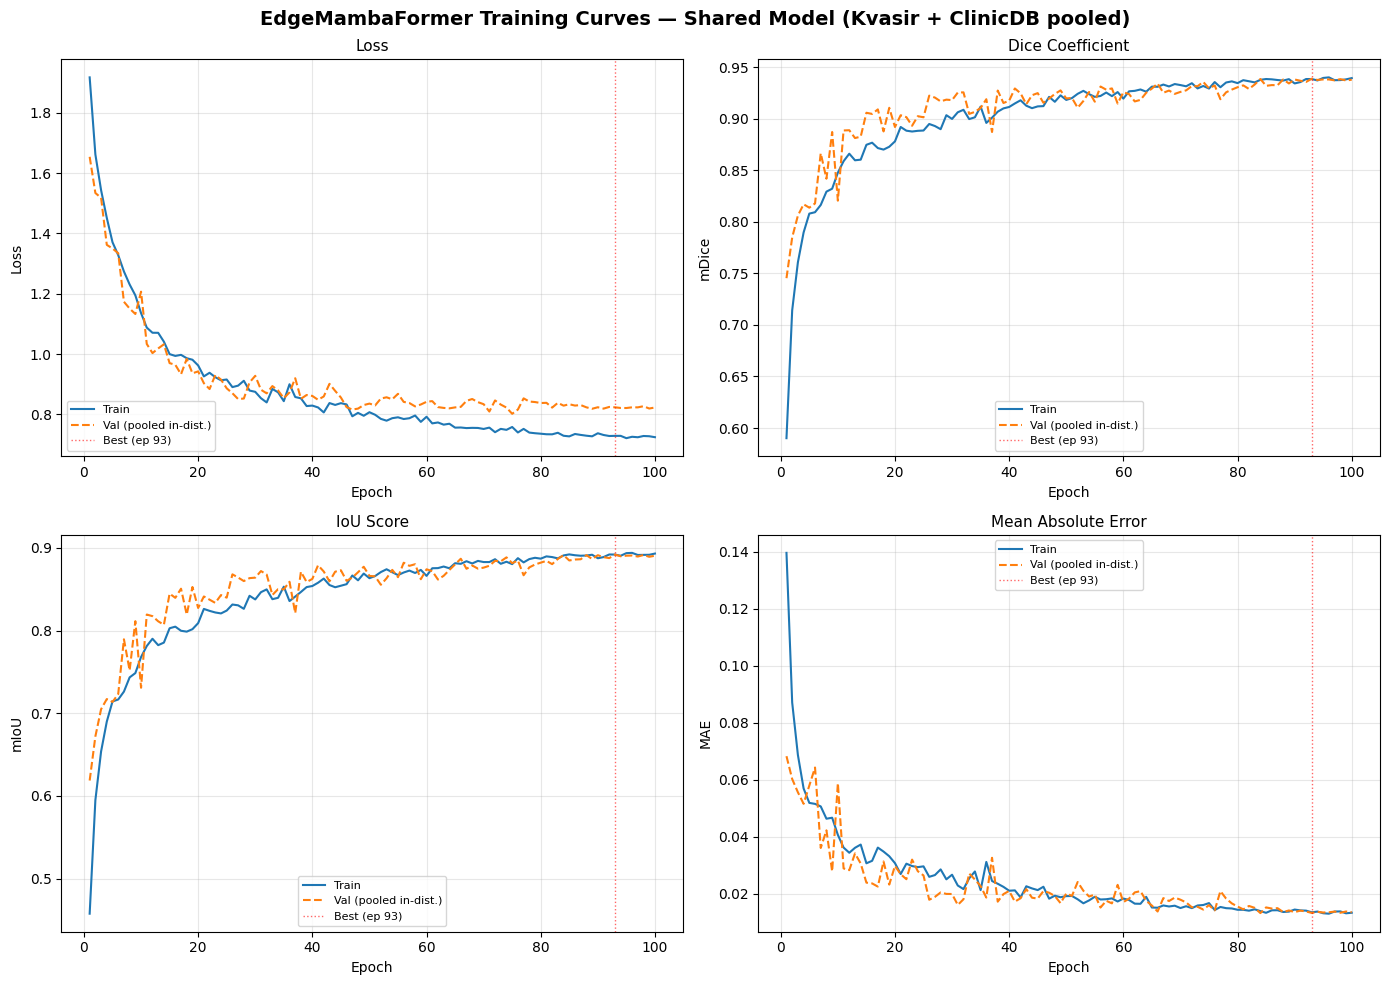

Best epoch: 93 with pooled Val Dice = 0.9389


In [16]:
epochs_ran = len(history['train_loss'])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EdgeMambaFormer Training Curves — Shared Model (Kvasir + ClinicDB pooled)', fontsize=14, fontweight='bold')

def plot_curve(ax, tr, vl, title, ylabel, ep_range):
    ax.plot(ep_range, tr, label='Train', linewidth=1.5)
    ax.plot(ep_range, vl, label='Val (pooled in-dist.)', linewidth=1.5, linestyle='--')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

plot_curve(axes[0,0], history['train_loss'], history['val_loss'], 'Loss', 'Loss', ep_range)
plot_curve(axes[0,1], history['train_dice'], history['val_dice'], 'Dice Coefficient', 'mDice', ep_range)
plot_curve(axes[1,0], history['train_iou'],  history['val_iou'],  'IoU Score', 'mIoU', ep_range)
plot_curve(axes[1,1], history['train_mae'],  history['val_mae'],  'Mean Absolute Error', 'MAE', ep_range)

best_ep = np.argmax(history['val_dice']) + 1
for ax in axes.flat:
    ax.axvline(best_ep, color='red', linewidth=1, linestyle=':', alpha=0.6, label=f'Best (ep {best_ep})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('training_curves_shared.png', dpi=150)
plt.show()
print(f'Best epoch: {best_ep} with pooled Val Dice = {history["val_dice"][best_ep-1]:.4f}')

## 13. Final Evaluation — Four Test Sets, One Fixed Model



In [20]:
# ── Reload the best checkpoint (selected on pooled in-distribution val Dice) ──
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']} (pooled val Dice={ckpt['best_dice']:.4f})")


@torch.no_grad()
def evaluate_test_set(model, pairs, cfg, device, name, threshold=0.5):
    """Runs the fixed model on one test set and returns per-image + mean metrics."""
    loader = make_loader(pairs, get_val_transforms(cfg['img_size']), cfg, shuffle=False)
    all_dice, all_iou, all_mae = [], [], []

    for imgs, masks in tqdm(loader, desc=f'Eval {name}', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        outputs  = model(imgs)
        pred_bin = (torch.sigmoid(outputs['pred']) > threshold).float()
        for b in range(imgs.shape[0]):
            p = pred_bin[b].view(-1); t = masks[b].view(-1)
            tp = (p * t).sum().item(); fp = (p * (1 - t)).sum().item(); fn = ((1 - p) * t).sum().item()
            all_dice.append(2 * tp / (2 * tp + fp + fn + 1e-8))
            all_iou.append(tp / (tp + fp + fn + 1e-8))
            all_mae.append((p - t).abs().mean().item())

    return {
        'name': name, 'n': len(pairs),
        'dice': float(np.mean(all_dice)), 'iou': float(np.mean(all_iou)), 'mae': float(np.mean(all_mae)),
        'per_image': {'dice': all_dice, 'iou': all_iou, 'mae': all_mae},
    }


test_sets = [
    ('Kvasir (in-dist.)',    kvasir_test),
    ('CVC-ClinicDB (in-dist.)', clinicdb_test),
    ('CVC-ColonDB (zero-shot)', colondb_pairs),
    ('ETIS (zero-shot)',        etis_pairs),
]

results = [evaluate_test_set(model, pairs, CFG, DEVICE, name) for name, pairs in test_sets]

print('\n' + '=' * 78)
print('  TABLE 1 -- SHARED-TRAINING PROTOCOL (comparable to FCA-Net / Polyp-PVT)')
print('=' * 78)
print(f'  {"Test set":26s} {"n":>5s}   {"mDice":>7s}  {"mIoU":>7s}  {"MAE":>7s}')
print('  ' + '-' * 74)
for r in results:
    print(f'  {r["name"]:26s} {r["n"]:5d}   {r["dice"]:7.4f}  {r["iou"]:7.4f}  {r["mae"]:7.4f}')
print('=' * 78)
print('  Compare directly against Table 1 baselines (U-Net, PraNet, TransUNet,')
print('  MSNet, SANet, Polyp-PVT, FCA-Net) -- same protocol, same test sets.')
print('=' * 78)

Loaded checkpoint from epoch 93 (pooled val Dice=0.9389)



  TABLE 1 -- SHARED-TRAINING PROTOCOL (comparable to FCA-Net / Polyp-PVT)
  Test set                       n     mDice     mIoU      MAE
  --------------------------------------------------------------------------
  Kvasir (in-dist.)            100    0.9365   0.8899   0.0168
  CVC-ClinicDB (in-dist.)       62    0.9428   0.8952   0.0075
  CVC-ColonDB (zero-shot)      380    0.7987   0.7142   0.0322
  ETIS (zero-shot)             196    0.7913   0.7064   0.0145
  Compare directly against Table 1 baselines (U-Net, PraNet, TransUNet,
  MSNet, SANet, Polyp-PVT, FCA-Net) -- same protocol, same test sets.


In [24]:
import shutil
from IPython.display import FileLink, display

# ── Copy checkpoint to /kaggle/working (Kaggle's downloadable output folder) ─
download_path = '/kaggle/working/edgemambaformer_best.pth'
shutil.copy(best_ckpt, download_path)

print(f"Checkpoint saved to: {download_path}")
print(f"Size: {os.path.getsize(download_path) / 1e6:.1f} MB")
print("\nClick below to download directly, or find it in the 'Output' tab on the right panel:")
display(FileLink(download_path))

Checkpoint saved to: /kaggle/working/edgemambaformer_best.pth
Size: 305.7 MB

Click below to download directly, or find it in the 'Output' tab on the right panel:


/kaggle/working/edgemambaformer_best.pth

In [ ]:
import base64
from IPython.display import HTML

download_path = '/kaggle/working/edgemambaformer_best.pth'
shutil.copy(best_ckpt, download_path)

size_mb = os.path.getsize(download_path) / 1e6
print(f"Checkpoint size: {size_mb:.1f} MB")

with open(download_path, 'rb') as f:
    b64 = base64.b64encode(f.read()).decode()

html = f'''<a download="edgemambaformer_best.pth"
   href="data:application/octet-stream;base64,{b64}"
   style="font-size:16px;">Click here to download edgemambaformer_best.pth ({size_mb:.1f} MB)</a>'''
display(HTML(html))

Checkpoint size: 305.7 MB


## 14. Save Results Summary

In [21]:
import json as _json
from datetime import datetime

summary = {
    'timestamp'  : datetime.now().isoformat(),
    'protocol'   : 'shared-training (pooled Kvasir+ClinicDB train, 4-way eval)',
    'config'     : {k: v for k, v in CFG.items() if k != 'data_roots'},
    'best_epoch' : ckpt['epoch'],
    'pooled_val_dice_at_best': ckpt['best_dice'],
    'results'    : [{'test_set': r['name'], 'n': r['n'], 'mDice': r['dice'], 'mIoU': r['iou'], 'MAE': r['mae']}
                     for r in results],
    'params_M'   : round(total_params / 1e6, 2),
}

with open('./shared_training_results.json', 'w') as f:
    _json.dump(summary, f, indent=2)

print('Saved to shared_training_results.json')
for r in summary['results']:
    print(f"  {r['test_set']:26s} mDice={r['mDice']:.4f}  mIoU={r['mIoU']:.4f}  MAE={r['MAE']:.4f}  (n={r['n']})")

Saved to shared_training_results.json
  Kvasir (in-dist.)          mDice=0.9365  mIoU=0.8899  MAE=0.0168  (n=100)
  CVC-ClinicDB (in-dist.)    mDice=0.9428  mIoU=0.8952  MAE=0.0075  (n=62)
  CVC-ColonDB (zero-shot)    mDice=0.7987  mIoU=0.7142  MAE=0.0322  (n=380)
  ETIS (zero-shot)           mDice=0.7913  mIoU=0.7064  MAE=0.0145  (n=196)
